<h2>Data Analytics- notebook,World Happiness Ranking</h2>

<h3><b>Dataset name:</b></h3>

World Happiness Ranking


<h3><b>Data source (url):</b></h3>

https://www.kaggle.com/datasets/anamvillalpando/world-happiness-ranking

<h3><b>Data format:</b></h3>

Single file-csv

<h3><b>Data description, features and limitations:</b></h3>

**World Happiness Data – Description, Features & Limitations**

This dataset shows how happy people are in different countries. The data comes from surveys where people rated their life from 0 (worst) to 10 (best). It also looks at what things might affect happiness, like money, health, and friendships.

**Key Features:**

* Happiness scores from people in each country
* Data on money (GDP), health, and freedom
* Info about generosity and trust in government
* Emotions like joy or sadness from recent days

**Good stuff:**

* Real answers from people around the world
* Many different things to compare with happiness
* Helps us understand what makes people feel happy

**Limitations:**

* Some data is estimated, not exact
* Not all countries answered every question
* It doesn’t update in real-time

<h4><b>Code: importing modules, custom functions and loading the data</b></h4>

In [1]:
# Importing the required data analytics modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt


# Loading the data
df = pd.read_csv("Happiness.csv")

In [2]:
# Info of the dataset (Happiness)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                153 non-null    object 
 1   Regional indicator                          153 non-null    object 
 2   Ladder score                                153 non-null    float64
 3   Standard error of ladder score              153 non-null    float64
 4   upperwhisker                                153 non-null    float64
 5   lowerwhisker                                153 non-null    float64
 6   Logged GDP per capita                       153 non-null    float64
 7   Social support                              153 non-null    float64
 8   Healthy life expectancy                     153 non-null    float64
 9   Freedom to make life choices                153 non-null    float64
 10  Generosity    

<h3><b>Code: Data clean-up procedure</b></h3>

In [3]:
df.isna().sum()
# as we can see we do not have any nan values in this dataset 
# so most probably we would be needing to remove some of the columns


Country name                                  0
Regional indicator                            0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       0
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         0
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           0
dtype: int64

<h3><b>Code: Data analysis</b></h3>

In [4]:
# Maximum Ladder Score 

print(df["Ladder score"].max())

7.808700085


In [5]:
# Minimum Ladder Score 
print(df["Ladder score"].min())

2.566900015


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_2180/1053218243.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Ladder score", y="Country name",
/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_2180/1053218243.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x="Ladder score", y="Country name",


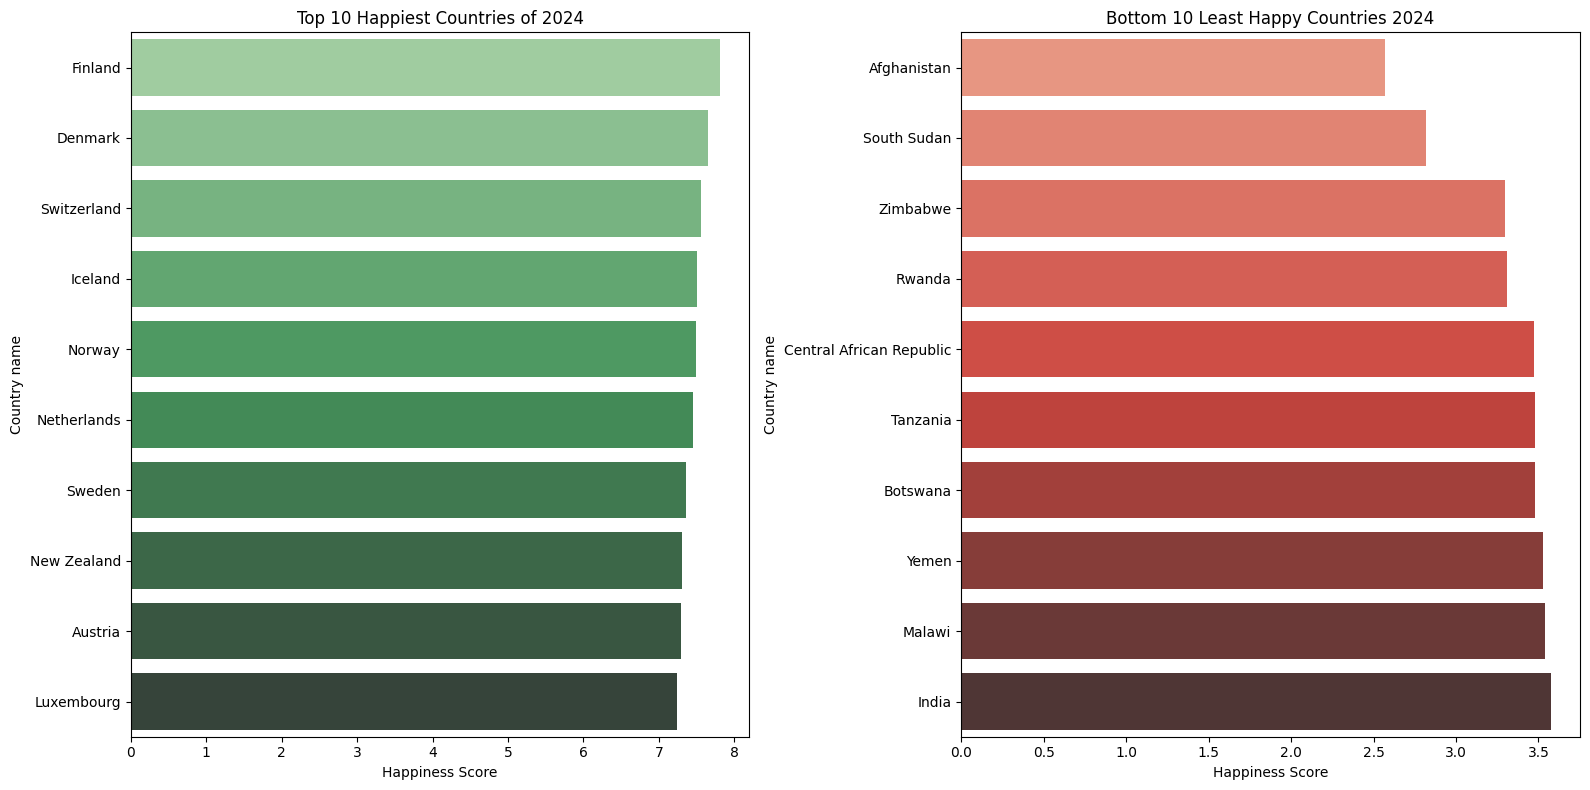

In [6]:
# TOP & BOTTOM 10 COUNTRIES (2024) 

# sorting by happiness score
df_sorted = df.sort_values("Ladder score", ascending=False)

# selecting top 10 and bottom 10
top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)[::-1]

# ceating side by side plots
fig, (image1, image2) = plt.subplots(1, 2, figsize=(16, 8))

# displaying top 10 countries
sns.barplot(data=top10, x="Ladder score", y="Country name",
            palette="Greens_d", ax=image1)

image1.set_title("Top 10 Happiest Countries of 2024")
image1.set_xlabel("Happiness Score")

# displaying bottom 10 countries
sns.barplot(data=bottom10, x="Ladder score", y="Country name",
            palette="Reds_d", ax=image2)

image2.set_title("Bottom 10 Least Happy Countries 2024")
image2.set_xlabel("Happiness Score")

# Adjusting layout presentation 
plt.tight_layout()
plt.show()


# Observation:

* Finland is the happiest country in 2024, leading the global rankings once again.
* Afghanistan is the least happy country, with other low-scoring nations mostly from conflict-affected or economically challenged regions.

/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_2180/644770062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


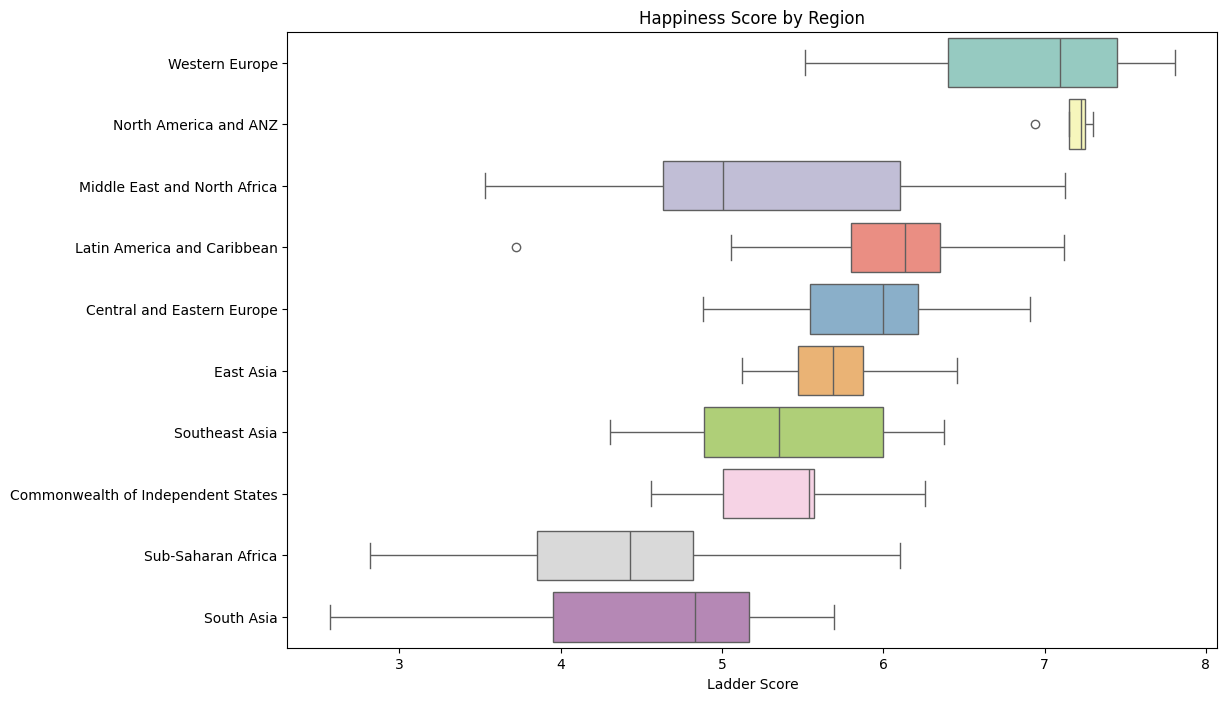

In [7]:
# REGIONAL COMPARISON 

plt.figure(figsize=(12, 8))

# Boxplot of happiness score by region
sns.boxplot(data=df,
            x="Ladder score",
            y="Regional indicator",
            palette="Set3")

# Labels
plt.title("Happiness Score by Region")
plt.xlabel("Ladder Score")
plt.ylabel("")

# Show plot
plt.show()


# Observation:

* Western Europe has the highest happiness scores.
* South Asia is much lower.
* Sub-Saharan Africa has a big mix — some countries do very well, while others score very low.

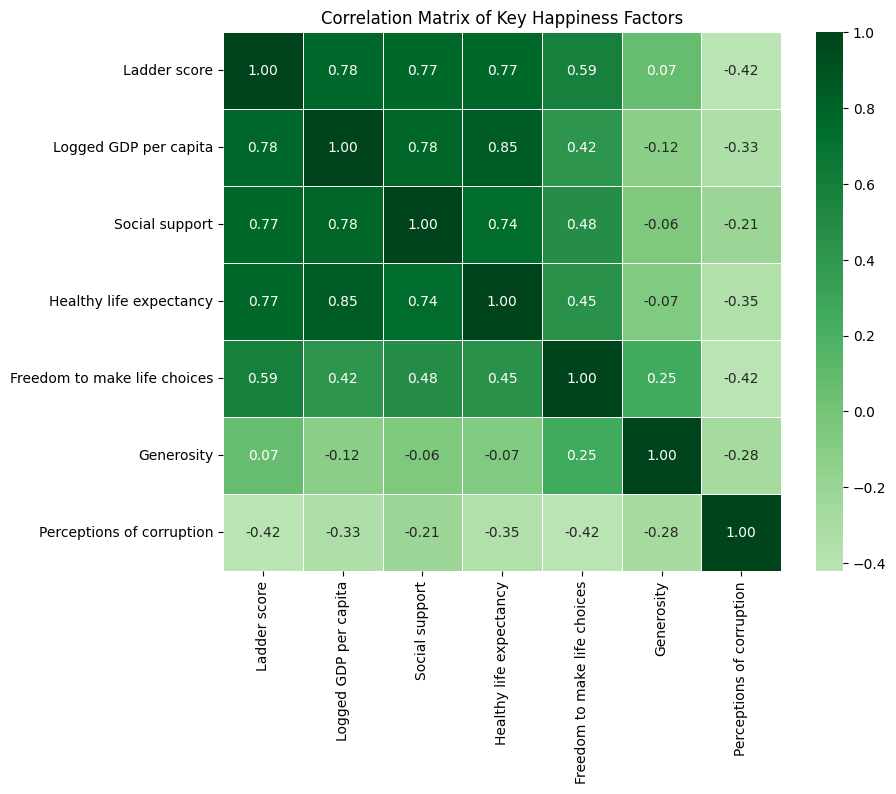

In [8]:
# ==================== 8. CORRELATION HEATMAP ====================

# Select the main features
features = [
    "Ladder score", "Logged GDP per capita", "Social support",
    "Healthy life expectancy", "Freedom to make life choices",
    "Generosity", "Perceptions of corruption"
]

# computing correlation matrix
corr = df[features].corr()

# Plotting heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr,
            annot=True,
            cmap="Greens",
            center=0,
            fmt=".2f",
            linewidths=0.5)

# displaying 
plt.title("Correlation Matrix of Key Happiness Factors")
plt.show()


# Observation

The ladder score shows strong correlations with several key factors, including GDP per capita, social support, and healthy life expectancy.
Freedom to make life choices also has a significant positive impact on the ladder score.
Additionally, social support is closely related to both healthy life expectancy and overall well-being.

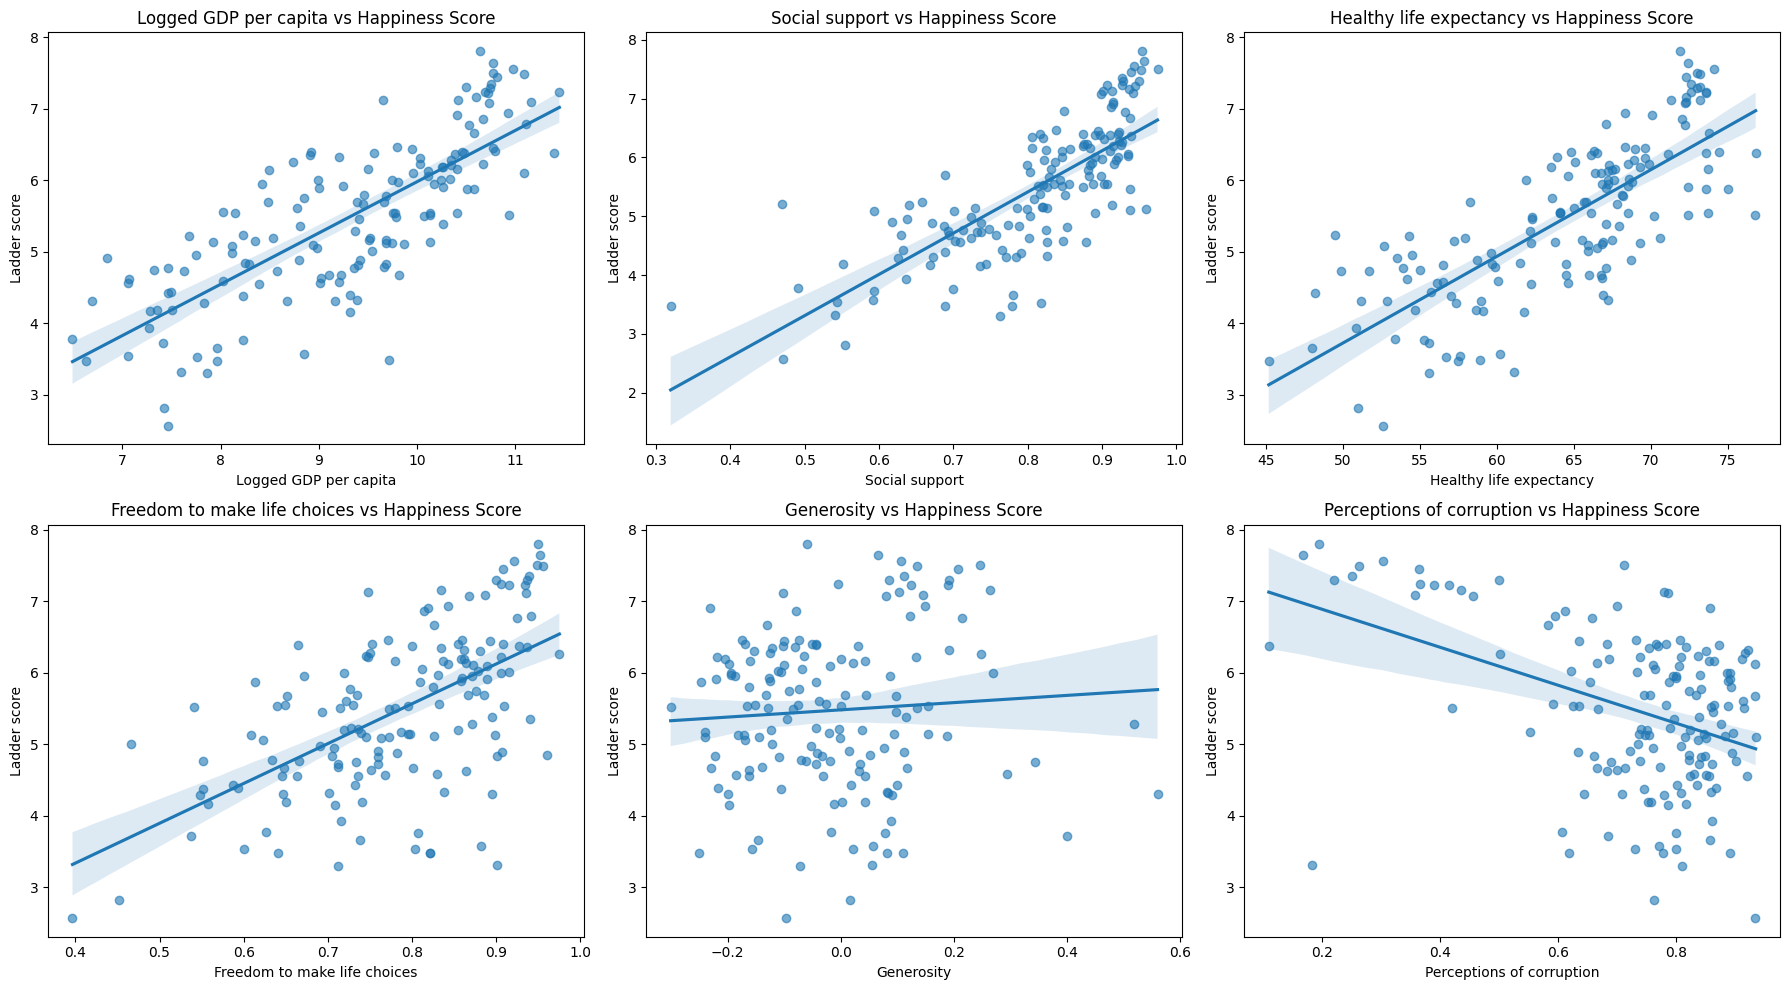

In [9]:
# ==================== 9. SCATTER PLOTS: Factors vs Happiness ====================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

factors = ["Logged GDP per capita", "Social support", "Healthy life expectancy",
            "Freedom to make life choices", "Generosity", "Perceptions of corruption"]

for i, factor in enumerate(factors):
    sns.regplot(data=df, x=factor, y="Ladder score", scatter_kws={'alpha':0.6}, ax=axes[i])
    axes[i].set_title(f"{factor} vs Happiness Score")

plt.tight_layout()
plt.show()

# Obervation:

* It shows that there is not enough data to draw a clear conclusion.
* The points on the plot are scattered, which makes it difficult to determine any strong relationship.
* This could mean that the ladder score is influenced by many different factors, or that the dataset is too small to provide meaningful insights — or possibly both.

<h3><b>Results and summary:</b></h3>

There isn’t enough data to make strong conclusions because the points on the chart are spread out.

The happiness score (ladder score) is connected to GDP, social support, and healthy life expectancy.

Freedom to make life choices also helps increase happiness.

Western Europe has the highest happiness scores.

South Asia has much lower scores.

Sub-Saharan Africa has a very wide range — some countries are happy, and some are not.

Finland is the happiest country in 2024.

Afghanistan is the least happy country, along with other countries that face problems like conflict or poverty.

<h3><b>Ideas for further improvements:</b></h3>

* The dataset can be better if we add a few more columns, such as:

* Year (to see changes over time)

* Population size

* Education level

* How much of the country is urban

* Environmental quality

* Other happiness scales like HDI

<h3><b>AI(ChatGPT) Used for:</b></h3>

<li> Comments and improving the writing rhythm language </li>
<li> Visualization ideas (like which types of graph has better visual as a audience) </li>
